# Predicting Smartphone Addiction — データの形を見てからモデルを選ぶ

Playground Series S6E8 のEDAとベースラインです。
目的変数は `addicted_label`(依存かどうかの2値)、評価指標は ROC-AUC。

## 先に結論

- 全特徴量に4〜20%の欠損があるが MCAR(z検定 + 多重比較補正で確認)。欠損フラグを足しても動かない
- スクリーンタイム系の3つが目的変数に対して急なS字を描く。3.9時間以下なら陽性率26%、9.5時間を超えるとほぼ100%
- このS字のせいで線形モデルが不利になる。ロジスティック回帰とLightGBMでAUCが0.05違った
- `notifications_per_day` と `app_opens_per_day` は目的変数との相関がほぼゼロ。それでも**この2列を抜くとAUCが0.019落ちる**。相関で切り捨てるところだった
- `daily_screen_time_hours` は内訳3列の合計 + 1.3時間くらい、という構造をしている

ベースラインは段階的に作って比べました(5-fold CV、特徴量は12列で固定)。

| モデル | CV AUC | 何の力を測っているか |
|---|---|---|
| `daily_screen_time_hours` 1本だけ(学習なし) | 0.86537 | 特徴量 |
| ロジスティック回帰 | 0.91148 | 線形モデル |
| LightGBM(ほぼ既定パラメータ) | 0.96349 | 木モデル |
| LightGBM(パラメータをチューニング) | 0.96668 | パラメータ |

LightGBM の Public LB は 0.96511。CVとの差が0.0016しかないので、
以降の改善はCVを見て判断できそうです。

パラメータの伸び(+0.0032)のうち **3分の2は `max_bin` の1行**でした。
その理由は第9章の最後と、別ノートブック
([`max_bin` はどこまで上げるべきか](https://www.kaggle.com/code/kitopl/max-bin))にあります。

## 目次

1. [準備](#1)
2. [データの全体像](#2)
3. [目的変数の分布](#3)
4. [欠損値 — ランダムに空いているのか?](#4)
5. [数値特徴量と目的変数の関係](#5)
6. [特徴量どうしの関係](#6)
7. [カテゴリ特徴量](#7)
8. [ここまでのまとめと方針](#8)
9. [ベースラインを段階的に作る](#9)
10. [モデルの評価](#10)
11. [まとめと次にやること](#11)

<a id="1"></a>
## 1. 準備

グラフの色とスタイルは最初にまとめて定義しておきます。
図中の文字は、フォント環境に左右されないよう英語にしています。

In [1]:
import time
import warnings

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# --- 配色定義 -----------------------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RED = "#e34948"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
# 青の単色ランプ(薄い→濃い): 大小の比較に使う
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#256abf", "#184f95"]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", BLUE_RAMP)
# 青↔灰↔赤の発散ランプ: 相関係数など符号のある量に使う
DIV_CMAP = LinearSegmentedColormap.from_list("div_br", [BLUE, "#f0efec", RED])

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK2,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "lines.linewidth": 2,
    "font.size": 9,
    "figure.dpi": 110,
})

データの読み込みです。Kaggle上でもローカルでも動くようにパスを自動判定します。

In [2]:
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
CANDIDATES = [
    KAGGLE_INPUT / "playground-series-s6e8",  # Kaggle 実行時
    Path("data"),                             # ローカル: プロジェクト直下から実行
    Path("../data"),                          # ローカル: notebooks/ から実行
]
DATA_DIR = next((p for p in CANDIDATES if (p / "train.csv").exists()), None)

if DATA_DIR is None and KAGGLE_INPUT.exists():
    # マウント先が変わっていても拾えるように探しておく
    found = next(KAGGLE_INPUT.glob("**/train.csv"), None)
    DATA_DIR = found.parent if found else None

if DATA_DIR is None:
    raise FileNotFoundError("train.csv が見つかりませんでした")

print(f"data dir: {DATA_DIR}")

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

TARGET = "addicted_label"
ID = "id"
NUM_COLS = [
    "age", "daily_screen_time_hours", "social_media_hours", "gaming_hours",
    "work_study_hours", "sleep_hours", "notifications_per_day",
    "app_opens_per_day", "weekend_screen_time",
]
CAT_COLS = ["gender", "stress_level", "academic_work_impact"]
FEATURES = NUM_COLS + CAT_COLS

print(f"train: {train.shape}")
print(f"test : {test.shape}")

data dir: /kaggle/input/competitions/playground-series-s6e8
train: (691369, 14)
test : (296302, 13)


<a id="2"></a>
## 2. データの全体像

まずは行数・列数と型の確認から。

In [3]:
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


特徴量は12個(数値9 + カテゴリ3)だけ。中身はこんな感じです。

| 特徴量 | 型 | 意味 |
|---|---|---|
| `age` | 数値 | 年齢(18〜35歳) |
| `daily_screen_time_hours` | 数値 | 平日の1日あたりスクリーンタイム(時間) |
| `social_media_hours` | 数値 | SNS利用時間(時間) |
| `gaming_hours` | 数値 | ゲーム時間(時間) |
| `work_study_hours` | 数値 | 仕事・学習でのスマホ利用時間(時間) |
| `sleep_hours` | 数値 | 睡眠時間(時間) |
| `notifications_per_day` | 数値 | 1日の通知数 |
| `app_opens_per_day` | 数値 | 1日のアプリ起動回数 |
| `weekend_screen_time` | 数値 | 週末のスクリーンタイム(時間) |
| `gender` | カテゴリ | 性別(Male / Female / Other) |
| `stress_level` | カテゴリ | ストレスレベル(Low / Medium / High) |
| `academic_work_impact` | カテゴリ | 学業・仕事への影響(Yes / No) |
| **`addicted_label`** | **目的変数** | **スマホ依存か否か(1 / 0)** |

In [4]:
train[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,662440.0,26.62,5.15,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.64,2.72,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.47,1.32,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.46,0.93,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.37,1.26,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.80,1.23,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.89,65.92,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.64,48.09,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.48,2.86,0.51,7.28,9.58,11.75,17.56


`age` は18〜35歳、`sleep_hours` は4.5〜9.0時間と、どれもきれいな範囲に収まっています。
外れ値処理に悩まされないのは合成データのありがたいところ。

### このデータが合成である根拠

推測ではなく主催者が明記しています。[Overview](https://www.kaggle.com/competitions/playground-series-s6e8/overview)
の "About the Tabular Playground Series" に
*"datasets that are synthetically generated from real-world data"* とあり、
**Synthetically-Generated Datasets** という節も立っています。
元になった実データも [Data](https://www.kaggle.com/competitions/playground-series-s6e8/data) ページで
*"inspired by the Smartphone Addiction Prediction Dataset"* と名前が出ています。

2点だけ補足します。

**Kaggle 一般の話ではありません。** 合成なのは Playground Series 固有です。
賞金やメダルのある通常のコンペは実データを使います。合成にする理由も同じ節に書かれていて、
*"ensuring test labels are not publicly available"* — つまり練習用シリーズとして
テストラベルを非公開に保つための設計です。

**主催者は生成の副産物(artifact)が残ることを認めています。**
同じ節に *"that goal is to produce datasets that have far fewer artifacts"* とあります。
artifact は JPEG のブロックノイズや MRI の偽像と同じ用法で、
意図した仕掛けではなく手法の副作用として残る痕跡のことです。減らすのが目標と書かれている以上、
望ましくないものという扱いです。第10章でこの artifact を実際に踏むことになります。

train と test で値域がズレていないかも見ておきます。

In [5]:
range_check = pd.DataFrame({
    "train_min": train[NUM_COLS].min(), "train_max": train[NUM_COLS].max(),
    "test_min": test[NUM_COLS].min(), "test_max": test[NUM_COLS].max(),
})
range_check

,train_min,train_max,test_min,test_max
age,18.00,35.00,18.00,35.00
daily_screen_time_hours,0.50,15.00,0.50,15.00
social_media_hours,0.00,8.00,0.00,7.85
gaming_hours,0.00,4.00,0.00,4.00
work_study_hours,0.00,6.00,0.00,6.00
sleep_hours,4.50,9.00,4.50,9.00
notifications_per_day,20.00,250.00,20.00,250.00
app_opens_per_day,15.00,180.00,15.00,180.00
weekend_screen_time,0.51,17.56,0.51,17.56


ほぼ一致しています(`social_media_hours` の上限が 8.00 vs 7.85 と違うくらい)。
分布シフトの心配はしなくてよさそうです。

<a id="3"></a>
## 3. 目的変数の分布

分類なのでクラスの偏りを最初に見ます。

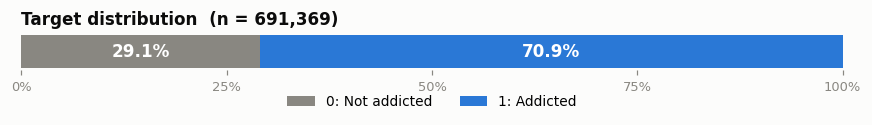

addicted_label
0    200895
1    490474


In [6]:
counts = train[TARGET].value_counts().sort_index()
rates = counts / counts.sum()

fig, ax = plt.subplots(figsize=(8, 1.5))
left = 0
for (label, rate), color, name in zip(rates.items(), [MUTED, BLUE], ["0: Not addicted", "1: Addicted"]):
    ax.barh([0], [rate], left=left, height=0.5, color=color, label=name)
    ax.text(left + rate / 2, 0, f"{rate:.1%}", ha="center", va="center",
            color="white", fontsize=11, fontweight="bold")
    left += rate

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.set_title(f"Target distribution  (n = {len(train):,})")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2)
for s in ["left", "bottom"]:
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(counts.to_string())

陽性が70.9%、陰性が29.1%。7:3くらいなので、オーバーサンプリングやクラス重み付けを
持ち出すほどではありません。

加えて評価指標が ROC-AUC です。AUC は予測値の順位しか見ないので、確率が0.5を跨ぐかどうかは
気にしなくてよく、不均衡の影響も受けにくい。順位を正しくつけることだけ考えれば大丈夫です。

<a id="4"></a>
## 4. 欠損値 — ランダムに空いているのか?

このデータの一番の特徴は欠損の多さです。ここは丁寧に見ておきます。

扱いを決める前に知りたいのは、欠損がランダムに空いているのか、
それとも欠損していること自体に意味があるのかです。統計では3つに分けて呼びます。

| 呼び方 | 欠損の決まり方 | このデータでの例え | 欠損フラグは効くか |
|---|---|---|---|
| **MCAR** (Missing Completely At Random) | 何とも関係なくランダム | 無作為に抜け落ちた | 効かない |
| **MAR** (Missing At Random) | **観測できている他の列**に依存 | 若い人ほど睡眠時間を答えない | 効く |
| **MNAR** (Missing Not At Random) | **その値自身**に依存 | 長時間の人ほど利用時間を答えない | 効く |

MAR / MNAR なら「欠損しているかどうか」を1/0の列にすると効きます。Kaggleでは定石ですが、
効くのは MCAR でない場合だけ。まず調べます。

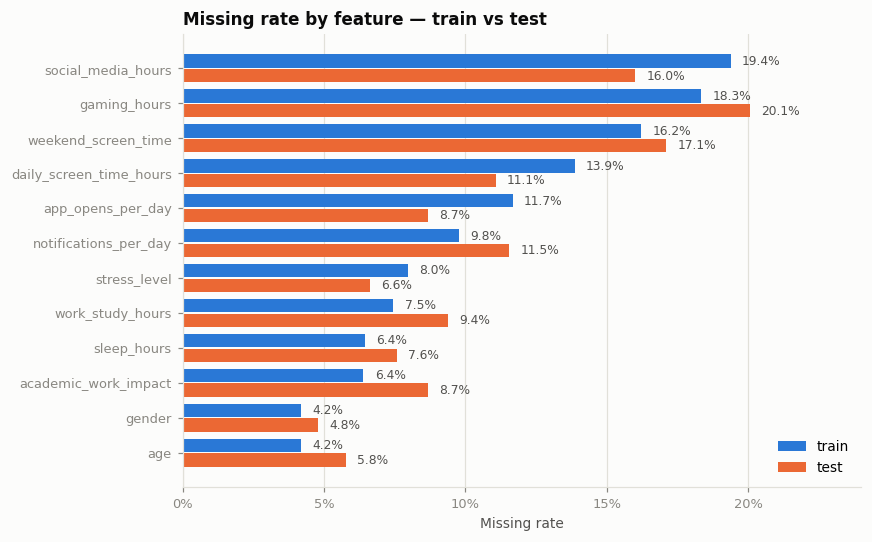

In [7]:
na_rate = pd.DataFrame({
    "train": train[FEATURES].isna().mean(),
    "test": test[FEATURES].isna().mean(),
}).sort_values("train")

y = np.arange(len(na_rate))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(y + 0.21, na_rate["train"], height=0.38, color=BLUE, label="train")
ax.barh(y - 0.21, na_rate["test"], height=0.38, color=ORANGE, label="test")
for i, (t, s) in enumerate(zip(na_rate["train"], na_rate["test"])):
    ax.text(t + 0.004, i + 0.21, f"{t:.1%}", va="center", fontsize=8, color=INK2)
    ax.text(s + 0.004, i - 0.21, f"{s:.1%}", va="center", fontsize=8, color=INK2)
ax.set_yticks(y)
ax.set_yticklabels(na_rate.index)
ax.set_xlim(0, 0.24)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Missing rate")
ax.set_title("Missing rate by feature — train vs test")
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

全部の特徴量に欠損があり、4%(`age`)から19%(`social_media_hours`)まで幅があります。

細かいですが、train と test で欠損率が微妙に違うのが気になります。
`social_media_hours` は train 19.4% に対して test 16.0% と3.4ポイント差。
欠損は後から人工的に空けられていて、その率が揃っていないようです。
値域は一致していたので、影響は小さいと思いますが頭には入れておきます。

### 本題:欠損に意味はあるか

「その列が欠損している行の陽性率」と「欠損していない行の陽性率」を比べます。
欠損に意味があるなら差が出るはずです。

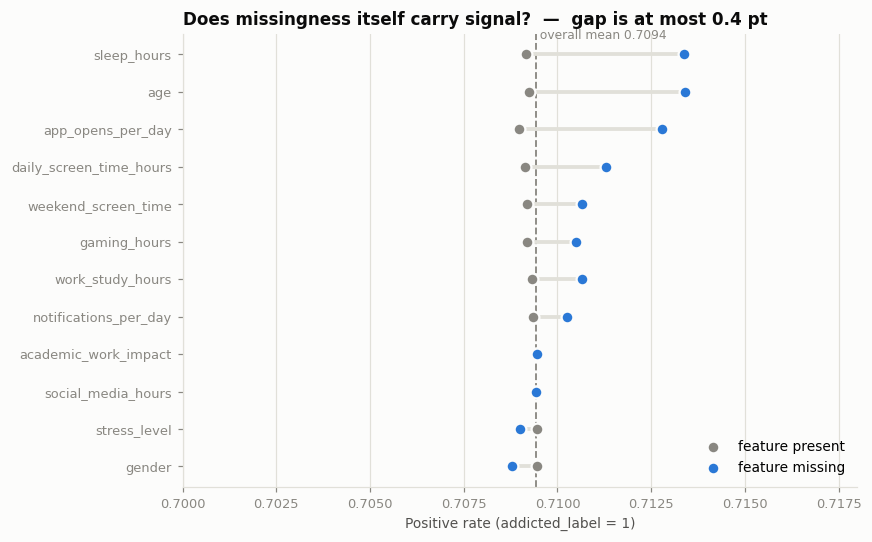

'                feature  missing  present  gap_pt\n                 gender 0.708790 0.709452   -0.07\n           stress_level 0.709001 0.709461   -0.05\n     social_media_hours 0.709415 0.709427   -0.00\n   academic_work_impact 0.709456 0.709422    0.00\n  notifications_per_day 0.710242 0.709336    0.09\n       work_study_hours 0.710645 0.709326    0.13\n           gaming_hours 0.710505 0.709182    0.13\n    weekend_screen_time 0.710654 0.709187    0.15\ndaily_screen_time_hours 0.711301 0.709122    0.22\n      app_opens_per_day 0.712787 0.708980    0.38\n                    age 0.713402 0.709251    0.42\n            sleep_hours 0.713377 0.709153    0.42'

In [8]:
rows = []
overall = train[TARGET].mean()
for c in FEATURES:
    m = train[c].isna()
    rows.append({
        "feature": c,
        "missing": train.loc[m, TARGET].mean(),
        "present": train.loc[~m, TARGET].mean(),
    })
na_target = pd.DataFrame(rows)
na_target["gap_pt"] = (na_target["missing"] - na_target["present"]) * 100
na_target = na_target.sort_values("gap_pt")

# ダンベルチャート(dumbbell plot): 2つの値を点で打ち線で結ぶ形式。差を見るのに向く
y = np.arange(len(na_target))
fig, ax = plt.subplots(figsize=(8, 5))
ax.axvline(overall, color=MUTED, ls="--", lw=1.2, zorder=1)
ax.text(overall, len(na_target) - 0.3, f" overall mean {overall:.4f}",
        color=MUTED, fontsize=8, va="top")
ax.hlines(y, na_target["present"], na_target["missing"], color=GRID, lw=2.5, zorder=2)
ax.scatter(na_target["present"], y, s=60, color=MUTED, label="feature present", zorder=3,
           edgecolor=SURFACE, linewidth=1.5)
ax.scatter(na_target["missing"], y, s=60, color=BLUE, label="feature missing", zorder=3,
           edgecolor=SURFACE, linewidth=1.5)
ax.set_yticks(y)
ax.set_yticklabels(na_target["feature"])
ax.set_xlabel("Positive rate (addicted_label = 1)")
ax.set_title("Does missingness itself carry signal?  —  gap is at most 0.4 pt")
ax.set_xlim(0.700, 0.718)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

na_target.assign(gap_pt=lambda d: d["gap_pt"].round(2)).to_string(index=False)

In [9]:
print(na_target.assign(gap_pt=lambda d: d["gap_pt"].round(3)).to_string(index=False))

                feature  missing  present  gap_pt
                 gender 0.708790 0.709452  -0.066
           stress_level 0.709001 0.709461  -0.046
     social_media_hours 0.709415 0.709427  -0.001
   academic_work_impact 0.709456 0.709422   0.003
  notifications_per_day 0.710242 0.709336   0.091
       work_study_hours 0.710645 0.709326   0.132
           gaming_hours 0.710505 0.709182   0.132
    weekend_screen_time 0.710654 0.709187   0.147
daily_screen_time_hours 0.711301 0.709122   0.218
      app_opens_per_day 0.712787 0.708980   0.381
                    age 0.713402 0.709251   0.415
            sleep_hours 0.713377 0.709153   0.422


横軸のレンジが狭いことに注目してください。全体平均0.7094に対して、
欠損時と非欠損時の差は最大でも0.42ポイント(`sleep_hours`)です。

ただし**「差が小さいから無関係」とは言えません**。69万行もあると、小さな差でも統計的には
検出できてしまいます。差の大きさではなく、偶然でこれくらい離れる確率を見るべきなので、
2標本比率のz検定にかけます。

In [10]:
from scipy import stats

rows = []
for c in FEATURES:
    m = train[c].isna()
    n1, n2 = m.sum(), (~m).sum()
    p1, p2 = train.loc[m, TARGET].mean(), train.loc[~m, TARGET].mean()
    p = train[TARGET].mean()
    z = (p1 - p2) / np.sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    rows.append({"feature": c, "n_missing": n1, "gap_pt": (p1 - p2) * 100,
                 "z": z, "p_value": 2 * (1 - stats.norm.cdf(abs(z)))})
ztest = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
print(ztest.round(4).to_string(index=False))

                feature  n_missing  gap_pt       z  p_value
      app_opens_per_day      80710  0.3807  2.2385   0.0252
            sleep_hours      44480  0.4224  1.8980   0.0577
                    age      28929  0.4151  1.5222   0.1280
daily_screen_time_hours      95854  0.2178  1.3785   0.1681
    weekend_screen_time     112063  0.1467  0.9903   0.3220
           gaming_hours     126821  0.1324  0.9383   0.3481
       work_study_hours      51518  0.1319  0.6342   0.5259
  notifications_per_day      67584  0.0906  0.4929   0.6221
                 gender      29034 -0.0662 -0.2433   0.8077
           stress_level      55148 -0.0460 -0.2281   0.8195
   academic_work_impact      44224  0.0034  0.0153   0.9878
     social_media_hours     133995 -0.0012 -0.0088   0.9930


最小のp値は `app_opens_per_day` の 0.025 です。単独で見れば有意水準5%を下回ります。

ただし**12列を検定している**ので、そのまま5%と比べるのは誤りです。
12回引けば、本当は差がなくても1回くらいは p < 0.05 が出ます。
Bonferroni 補正なら閾値は 0.05 / 12 = 0.0042 で、どの列も超えません。

つまり「欠損の有無で陽性率が変わる」とは言えない、が結論です。

念のため「1行あたりの欠損個数」も見ておきます。欠損が多い行ほど依存、みたいな
パターンがあればそれも特徴量になるので。

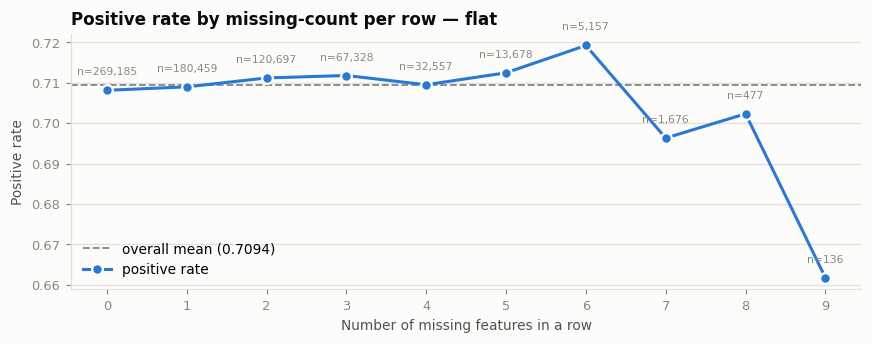

In [11]:
n_missing = train[FEATURES].isna().sum(axis=1)
by_nmiss = train.groupby(n_missing)[TARGET].agg(["mean", "size"])
by_nmiss = by_nmiss[by_nmiss["size"] >= 100]  # サンプル数が少ない領域は除外

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.axhline(overall, color=MUTED, ls="--", lw=1.2, label=f"overall mean ({overall:.4f})")
ax.plot(by_nmiss.index, by_nmiss["mean"], marker="o", ms=7, color=BLUE,
        markeredgecolor=SURFACE, markeredgewidth=1.5, label="positive rate")
for x, (rate, size) in by_nmiss.iterrows():
    ax.annotate(f"n={size:,.0f}", (x, rate), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=7, color=MUTED)
ax.set_xlabel("Number of missing features in a row")
ax.set_ylabel("Positive rate")
ax.set_title("Positive rate by missing-count per row — flat")
ax.set_xticks(by_nmiss.index)
ax.grid(axis="y")
ax.set_axisbelow(True)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

こちらも 0.708〜0.719 の狭い範囲で平坦。右端が暴れているのはサンプル数が少ないせいです。

### 欠損は MCAR と見てよさそう

ということで、欠損フラグを作っても効果は期待できないはずです。
ただしこれはまだ**予想**なので、[第10章](#10)で実際に足して測ります。
「効かないはず」で済ませた列が実は主力だった、という失敗を同じノートブックの中でやるので、
予想を書いたら測る、を通します。

代わりに LightGBM の欠損処理に任せます。LightGBM は欠損を補完せず、
分岐のどちら側に送るかを学習で決めてくれるので、そもそも埋める必要がありません。

<a id="5"></a>
## 5. 数値特徴量と目的変数の関係

どの特徴量が効くかを見ます。ただし相関係数だけだと直線的な関係しか測れないので、
関係の「形」まで見ておきます。ここが分かると線形モデルで足りるか木が要るかを判断できます。

やり方は単純で、特徴量を値の大きさで20等分して、各ビンの陽性率をプロットするだけです。

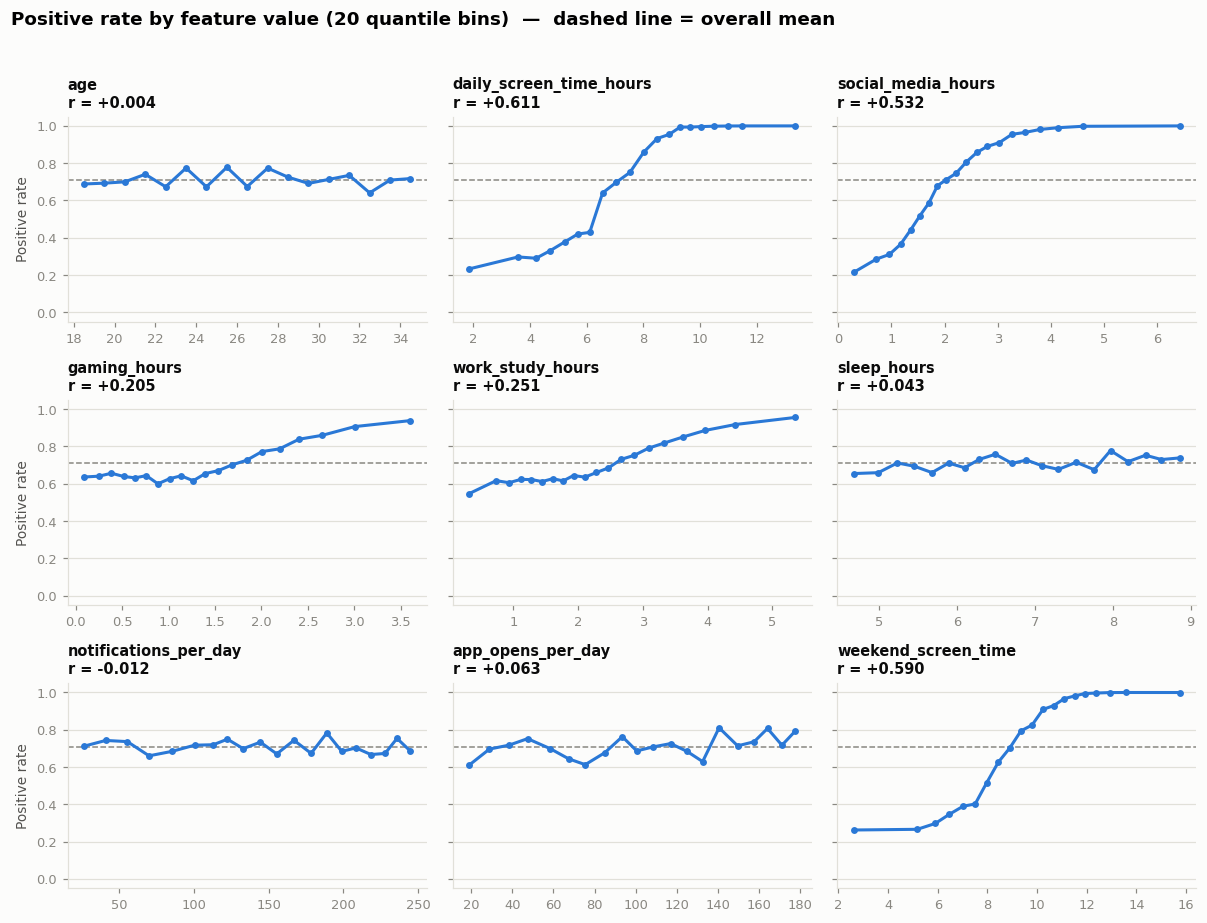

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(11, 8.5), sharey=True)
corr = train[NUM_COLS].corrwith(train[TARGET])

for ax, c in zip(axes.ravel(), NUM_COLS):
    sub = train[[c, TARGET]].dropna()
    bins = pd.qcut(sub[c], 20, duplicates="drop")
    g = sub.groupby(bins, observed=True)[TARGET].mean()
    centers = [iv.mid for iv in g.index]

    ax.axhline(overall, color=MUTED, ls="--", lw=1)
    ax.plot(centers, g.values, marker="o", ms=3.5, color=BLUE)
    ax.set_title(f"{c}\nr = {corr[c]:+.3f}", fontsize=9.5)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis="y")
    ax.set_axisbelow(True)

for ax in axes[:, 0]:
    ax.set_ylabel("Positive rate")
fig.suptitle("Positive rate by feature value (20 quantile bins)  —  dashed line = overall mean",
             x=0.008, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

きれいに3グループに分かれました。

**① S字を描く3つ** — `daily_screen_time_hours` (r=+0.61)、`weekend_screen_time` (+0.59)、
`social_media_hours` (+0.53)。単調増加ですが直線ではありません。数字でも見てみます。

In [13]:
# ここだけ十分位(件数が等しい10区間)にして数字で出す。グラフの20等分より1本が太いので読みやすい
sub = train[["daily_screen_time_hours", TARGET]].dropna()
deciles = pd.qcut(sub["daily_screen_time_hours"], 10)
print(sub.groupby(deciles, observed=True)[TARGET].agg(["mean", "size"]).round(4).to_string())

                           mean   size
daily_screen_time_hours               
(0.499, 3.97]            0.2651  60024
(3.97, 4.96]             0.3104  59307
(4.96, 5.89]             0.3986  59443
(5.89, 6.8]              0.5343  59593
(6.8, 7.77]              0.7234  59671
(7.77, 8.7]              0.8953  59671
(8.7, 9.47]              0.9743  60152
(9.47, 10.25]            0.9947  58917
(10.25, 11.24]           0.9987  59730
(11.24, 15.0]            0.9997  59007


**十分位(decile)** は、値の順に並べて件数が等しい10区間に分けたものです
(1区間あたり約6万行)。グラフのほうは20等分なので点が20個、こちらは表の行が10個になります。

3.97時間以下だと陽性率26.5%、9.47時間を超えると99.5%以上。
6〜9時間のところで一気に立ち上がっています。

**② そこそこ効く2つ** — `work_study_hours` (+0.25)、`gaming_hours` (+0.21)。
増えてはいきますが、上端でも8〜9割で頭打ちにはなりません。

**③ 効かなそうな4つ** — `age` (+0.004)、`sleep_hours` (+0.043)、
`app_opens_per_day` (+0.063)、`notifications_per_day` (−0.012)。
上の20等分のグラフも水平です。

ただし20等分は1本あたり3万行前後(`notifications_per_day` なら31,189行)をまとめた
粗い見方で、「この粒度で平坦」以上のことは言えません。
[第10章](#10)でこの4つのうち2つに足をすくわれます。

### S字が急なので木ベースが有利なはず

「9.5時間を超えたらほぼ確実に依存」のような閾値の話は決定木の得意分野です。
逆にロジスティック回帰は特徴量に対して線形にしか反応できないので苦しいはず。
[第9章](#9)で実際に差が出るか確かめます。

ついでに分布の重なりも見ておきます。重なりが小さいほど、その列だけでクラスを分けられます。

横軸はその列の値、縦軸は密度です。陽性・陰性で人数が7:3と違うので、
`density=True` で各クラスの面積を1に揃えています(そうしないと陽性側が単に高くなるだけで
形が比べられません)。縦軸の目盛りは形だけを見たいので消しています。

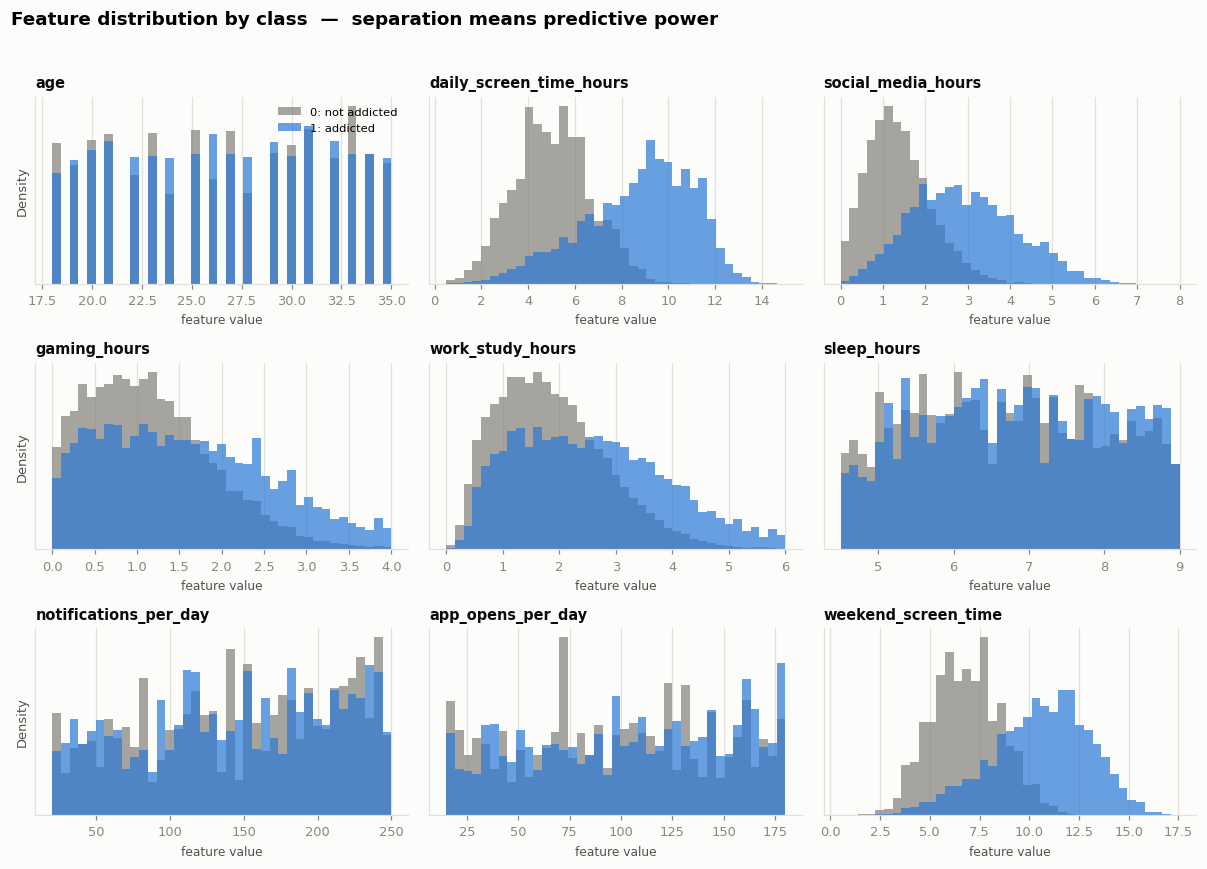

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for ax, c in zip(axes.ravel(), NUM_COLS):
    lo, hi = train[c].min(), train[c].max()
    bins = np.linspace(lo, hi, 40)
    ax.hist(train.loc[train[TARGET] == 0, c], bins=bins, color=MUTED, alpha=0.75,
            label="0: not addicted", density=True)
    ax.hist(train.loc[train[TARGET] == 1, c], bins=bins, color=BLUE, alpha=0.7,
            label="1: addicted", density=True)
    ax.set_title(c, fontsize=9.5)
    ax.set_xlabel("feature value", fontsize=8)
    ax.set_yticks([])   # 形だけを比べたいので目盛りは消す
    ax.grid(axis="x")
    ax.set_axisbelow(True)

for ax in axes[:, 0]:
    ax.set_ylabel("Density", fontsize=8.5)
axes[0, 0].legend(loc="upper right", fontsize=7.5)
fig.suptitle("Feature distribution by class  —  separation means predictive power",
             x=0.008, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

スクリーンタイム系はピークがはっきりずれています。
逆に `age`・`sleep_hours`・`notifications_per_day`・`app_opens_per_day` は完全に重なっていて、
単独では何も分けられません。

<a id="6"></a>
## 6. 特徴量どうしの関係

特徴量間の相関を見ると、データがどう作られたかが透けて見えます。
それが分かると、どんな特徴量を足せばよさそうかのヒントになります。

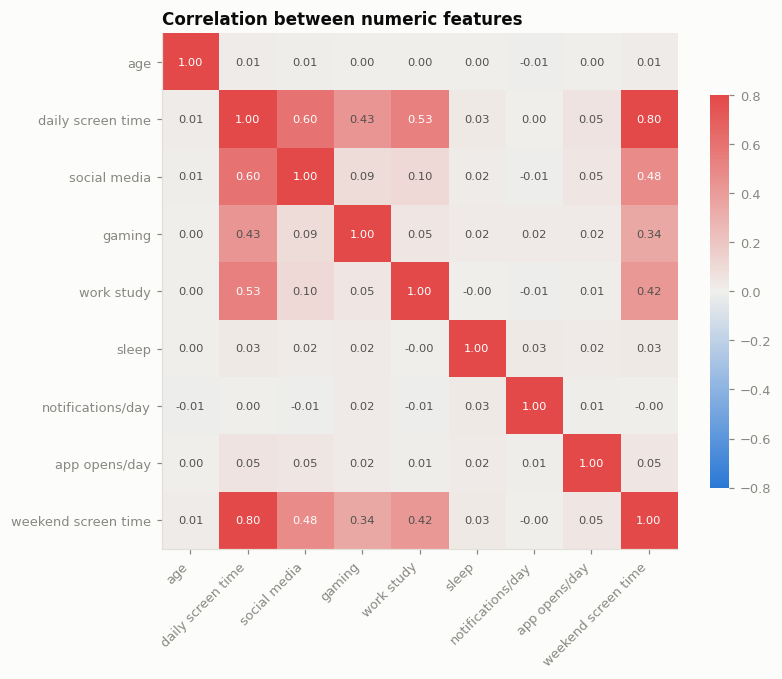

In [15]:
cm = train[NUM_COLS].corr()
labels = [c.replace("_hours", "").replace("_per_day", "/day").replace("_", " ") for c in NUM_COLS]

fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(cm.values, cmap=DIV_CMAP, vmin=-0.8, vmax=0.8)
ax.set_xticks(range(len(NUM_COLS)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(NUM_COLS)), labels)
for i in range(len(NUM_COLS)):
    for j in range(len(NUM_COLS)):
        v = cm.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(v) > 0.45 else INK2)
ax.set_title("Correlation between numeric features")
cbar = fig.colorbar(im, ax=ax, shrink=0.75)
cbar.outline.set_visible(False)
cbar.ax.tick_params(color=MUTED, labelcolor=MUTED)
plt.tight_layout()
plt.show()

`daily_screen_time_hours` がハブになっています。
`weekend_screen_time` (0.80)、`social_media_hours` (0.60)、`work_study_hours` (0.53)、
`gaming_hours` (0.43) と軒並み相関がある一方、内訳同士(SNSとゲームなど)は 0.05〜0.10 で無相関。

内訳を独立に作って、その合計を総量にしたのでは? と推測できます。確かめてみます。

In [16]:
parts = train[["social_media_hours", "gaming_hours", "work_study_hours",
               "daily_screen_time_hours"]].dropna()
parts_sum = parts[["social_media_hours", "gaming_hours", "work_study_hours"]].sum(axis=1)
residual = parts["daily_screen_time_hours"] - parts_sum

print(f"内訳3つの合計と daily_screen_time_hours の相関 : {parts_sum.corr(parts['daily_screen_time_hours']):.4f}")
print(f"内訳合計の平均                                 : {parts_sum.mean():.3f} h")
print(f"daily_screen_time_hours の平均                 : {parts['daily_screen_time_hours'].mean():.3f} h")
print(f"\n残差 (daily - 内訳合計) の分布:")
print(residual.describe().round(3).to_string())
print(f"\n残差が負(合計が総量を超える)の割合: {(residual < 0).mean():.4%}")

内訳3つの合計と daily_screen_time_hours の相関 : 0.8382
内訳合計の平均                                 : 6.295 h
daily_screen_time_hours の平均                 : 7.638 h

残差 (daily - 内訳合計) の分布:
count    421427.000
mean          1.343
std           1.480
min           0.000
25%           0.460
50%           0.750
75%           1.460
max          11.530

残差が負(合計が総量を超える)の割合: 0.0000%


残差が一度も負にならず(0%)、中央値0.75時間、平均1.34時間。予想どおりでした。

```
daily_screen_time_hours = social_media + gaming + work_study + その他(0以上)
```

この制約は [S6E8 — Lookup-Transformer](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
(tamerlanomralinov)がより厳密に測っています。train+test 859,029行で違反ゼロ、
残差そのものが単独で AUC 0.765、そして**残差がちょうど0の行が546行**。
残差0は「スクリーンタイムが内訳3つで説明しつくされていて余りがない人」で、
つまり不等式の等号が成立する行です。これがあるので `≥` であって `>` ではないと分かります。

同ノートブックには「**軸並行分割の組み合わせでは4項の線形結合を作れないので、
木は自力でこれを見つけられない**」という指摘もあります。少し補足すると:

決定木の分岐は必ず「`gaming_hours` は2.5以下か?」のように**1列だけを見た不等式**です。
特徴量空間で見ると境界が必ず座標軸と平行になるので、木が表せる領域は「箱」の集まりです。
一方 `daily − social − gaming − work_study` は**4列を同時に足し引きした量**で、
境界は斜めの面になります。斜めの面は箱の階段でいくらでも近似できますが、正確には表せません。
だから**この列は自分で作って渡さないと木は使えない**わけです。

週末のほうも見ておきます。

In [17]:
wk = train[["daily_screen_time_hours", "weekend_screen_time"]].dropna()
ratio = wk["weekend_screen_time"] / wk["daily_screen_time_hours"]
print("weekend / daily の比率:")
print(ratio.describe().round(3).to_string())

weekend / daily の比率:
count    517906.000
mean          1.330
std           0.498
min           0.085
25%           1.075
50%           1.241
75%           1.452
max          20.440


週末は平日の1.24倍(中央値)。だいたい「平日 × 1.2〜1.5」で作られていそうです。

### `notifications_per_day` と `app_opens_per_day` は相関から浮いている

相関行列でこの2列だけ、他のどの列とも |r| ≤ 0.05 です。目的変数とも
`app_opens_per_day` が +0.063、`notifications_per_day` が −0.012 でほぼゼロ。

ここまでの材料だけなら「独立なノイズとして生成された列」と結論したくなります。
実際そう判断しかけたのですが、後で LightGBM の重要度を見るとこの2つが上位に来ます。
相関と重要度が食い違ったときにどちらを信じるかは[第10章](#10)で決着をつけます。

### 派生特徴量のアイデア

構造が見えたので、こんな列が作れそうです(今回はベースラインまでなので実装は次回)。

- `daily - (social + gaming + work_study)` … 「その他」の利用時間
- `weekend / daily` … 週末に偏っているか
- `social / daily` … スクリーンタイムのうちSNSの割合

<a id="7"></a>
## 7. カテゴリ特徴量

カテゴリは相関係数で測れないので、水準ごとの陽性率を見ます。

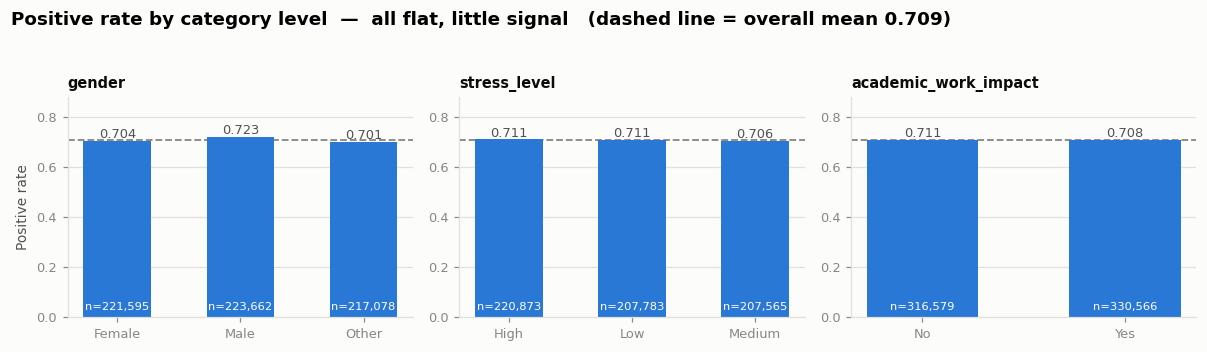

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, c in zip(axes, CAT_COLS):
    g = train.groupby(c, observed=True)[TARGET].agg(["mean", "size"]).sort_index()
    ax.axhline(overall, color=MUTED, ls="--", lw=1.2, zorder=1)
    ax.bar(g.index.astype(str), g["mean"], color=BLUE, width=0.55, zorder=2)
    for i, (rate, size) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, rate + 0.012, f"{rate:.3f}", ha="center", fontsize=8.5, color=INK2)
        ax.text(i, 0.03, f"n={size:,.0f}", ha="center", fontsize=7.5, color="white")
    ax.set_ylim(0, 0.88)
    ax.set_title(c, fontsize=9.5)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("Positive rate")
fig.suptitle(f"Positive rate by category level  —  all flat, little signal"
             f"   (dashed line = overall mean {overall:.3f})",
             x=0.008, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

3つとも見事に平坦でした。

- `gender`: 0.701〜0.723(最大差 2.2pt)
- `stress_level`: 0.706〜0.711(最大差 0.6pt)
- `academic_work_impact`: 0.708〜0.711(最大差 0.3pt)

各水準のサンプル数(n=)がほぼ均等なのも目を引きます。実データの調査ならここまで揃わない印象ですが、
生成の仕方は公開されていないので、これは根拠のある話ではなく私の印象です。

「ストレスが高い人ほど依存」みたいな関係がありそうなものですが、このデータにはありません。
カテゴリ3列は予測にほとんど効かないと見ておきます。

<a id="8"></a>
## 8. ここまでのまとめと方針

分かったことを並べると、

- 欠損は全列にあるがランダム → フラグは作らない。欠損を扱えるモデルを選ぶ
- 主要3列が急なS字 → 決定木ベースが有利そう
- `age` / `sleep_hours` / `notifications_per_day` / `app_opens_per_day` は無情報に見える([第10章](#10)で覆ります)
- カテゴリ3列も無情報。エンコーディングに凝る意味は薄い
- 総量 = 内訳の合計 + 残差 という構造。派生特徴量のネタになる
- 外れ値なし、train/test の値域も一致 → クレンジングは不要
- クラス比7:3 + ROC-AUC → 不均衡対策も不要

というわけで、**前処理は最小限で LightGBM** という方針で進めます。
特徴量エンジニアリングはベースラインができてから。

<a id="9"></a>
## 9. ベースラインを段階的に作る

いきなりLightGBMを回すのではなく、簡単なものから順に作ります。

- **A**: `daily_screen_time_hours` 1本だけ。最強の列だけでどこまで行くかの下限
- **B**: ロジスティック回帰。線形モデルの到達点
- **C**: LightGBM(ほぼ既定パラメータ)
- **D**: そのLightGBMのパラメータだけを詰めたもの

段階を踏むと、スコアのどこまでが特徴量の力で、どこからがモデルの力で、
どこからがパラメータの力かを切り分けられます。
「LightGBMで0.96出ました」だけだと、それが分からないので。

**特徴量は12列のまま固定**します。派生列を足すと切り分けが濁るので、
特徴量エンジニアリングはこのノートブックでは扱いません。

評価は共通で 5-fold の StratifiedKFold です。

In [19]:
X = train[FEATURES]
y_true = train[TARGET]
X_test = test[FEATURES]

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
folds = list(skf.split(X, y_true))
results = {}   # モデル名 -> CV AUC
oof_store = {} # モデル名 -> out-of-fold 予測

### A: 1列だけ

`daily_screen_time_hours` の値をそのまま予測値として使います。学習はしません。
AUC は順位しか見ないので、単調増加の関係さえあれば学習なしでもスコアが出ます。
(欠損は中央値で埋めます)

In [20]:
single = X["daily_screen_time_hours"].fillna(X["daily_screen_time_hours"].median())
auc_single = roc_auc_score(y_true, single)
results["A: single feature"] = auc_single
oof_store["A: single feature"] = single.to_numpy()
print(f"A: daily_screen_time_hours 単体の AUC = {auc_single:.5f}")

A: daily_screen_time_hours 単体の AUC = 0.86537


学習なし・1列だけで 0.865。この列の強さが分かります。
以降のモデルはこれを超えて初めて意味がある、というラインです。

### B: ロジスティック回帰

線形モデルは欠損を扱えずスケールにも敏感なので、前処理が要ります。

- 数値: 中央値で補完 → 標準化
- カテゴリ: One-Hot(欠損は独立したカテゴリ扱い)

これを `Pipeline` にまとめておくと、前処理が各foldの学習データだけから計算されるので、
検証データの情報が漏れません。地味ですが大事なところです。

具体的にはこういうことです。中央値補完は「中央値」、標準化は「平均と標準偏差」を計算します。
これを**分割前の全学習データ**で計算してしまうと、検証foldの値もその統計量に混ざります。
モデルは間接的に検証データを覗いたことになり、CVが実際より良く出ます。
`Pipeline` を CV ループの中に置けば、foldごとに学習側だけから計算し直されます。

今回の中央値補完なら漏れはごく僅かです(69万行と55万行の中央値はほぼ同じ)。
ただし target encoding のように**目的変数を使う前処理では致命的**になるので、
最初からこの形に揃えておくのが安全です。

In [21]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUM_COLS),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="__NA__")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
    ]), CAT_COLS),
])

lr_pipe = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, C=1.0)),
])

oof_lr = np.zeros(len(X))
for fold, (tr_idx, va_idx) in enumerate(folds):
    lr_pipe.fit(X.iloc[tr_idx], y_true.iloc[tr_idx])
    oof_lr[va_idx] = lr_pipe.predict_proba(X.iloc[va_idx])[:, 1]
    print(f"  fold {fold}: AUC = {roc_auc_score(y_true.iloc[va_idx], oof_lr[va_idx]):.5f}")

auc_lr = roc_auc_score(y_true, oof_lr)
results["B: logistic regression"] = auc_lr
oof_store["B: logistic regression"] = oof_lr
print(f"\nB: ロジスティック回帰の OOF AUC = {auc_lr:.5f}")

  fold 0: AUC = 0.91039
  fold 1: AUC = 0.91082
  fold 2: AUC = 0.91193
  fold 3: AUC = 0.91267
  fold 4: AUC = 0.91160

B: ロジスティック回帰の OOF AUC = 0.91148


0.911。1列だけのときから +0.046 です。
残り11列を足した割には伸びていません。S字を表現できていないせいでしょう。

### C: LightGBM

第8章の方針どおり、前処理はほぼしません。

- 欠損: 埋めない。LightGBM が左右どちらの枝に送るかを学習で決める
- カテゴリ: `category` 型にするだけ

木の本数は early stopping に任せます(100回改善しなければ打ち切り)。

**木の本数とは。** LightGBM のような勾配ブースティングは、木を1本ずつ順番に足していきます。
2本目は1本目の外れ具合を、3本目はそこまでの外れ具合を補正する、という形で積み上がります。
だから本数が多いほど表現力が上がり、いずれ学習データの誤差まで覚えて過学習します。

**early stopping とは。** 何本が最適かは事前に分かりません。そこで `num_boost_round=2000`
を上限として置き、検証データのAUCを1本ごとに見張ります。100本足しても改善しなければ
そこで打ち切り、**最良だった反復のモデル**を採用します。

1つ罠があります。**上限に張り付くと early stopping は発動しません。**
打ち切られないまま2000本目のモデルを読むことになるので、
「まだ伸びる余地があるスコア」を実力と勘違いします。`best_iteration` が上限と同じなら、
上限を上げて回し直す必要があります。

In [22]:
X_lgb, X_test_lgb = X.copy(), X_test.copy()
for c in CAT_COLS:
    X_lgb[c] = X_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "verbose": -1,
    "seed": 42,
}

oof_lgb = np.zeros(len(X_lgb))
test_pred = np.zeros(len(X_test_lgb))
importances = []
best_iters = []

for fold, (tr_idx, va_idx) in enumerate(folds):
    dtrain = lgb.Dataset(X_lgb.iloc[tr_idx], label=y_true.iloc[tr_idx], categorical_feature=CAT_COLS)
    dvalid = lgb.Dataset(X_lgb.iloc[va_idx], label=y_true.iloc[va_idx], categorical_feature=CAT_COLS,
                         reference=dtrain)
    model = lgb.train(
        params, dtrain, num_boost_round=2000, valid_sets=[dvalid],
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
    )
    oof_lgb[va_idx] = model.predict(X_lgb.iloc[va_idx], num_iteration=model.best_iteration)
    test_pred += model.predict(X_test_lgb, num_iteration=model.best_iteration) / N_SPLITS
    importances.append(model.feature_importance(importance_type="gain"))
    best_iters.append(model.best_iteration)
    print(f"  fold {fold}: AUC = {roc_auc_score(y_true.iloc[va_idx], oof_lgb[va_idx]):.5f}"
          f"  (best_iter = {model.best_iteration})")

auc_lgb = roc_auc_score(y_true, oof_lgb)
results["C: LightGBM"] = auc_lgb
oof_store["C: LightGBM"] = oof_lgb
print(f"\nC: LightGBM の OOF AUC = {auc_lgb:.5f}")

  fold 0: AUC = 0.96254  (best_iter = 1353)
  fold 1: AUC = 0.96333  (best_iter = 1850)
  fold 2: AUC = 0.96386  (best_iter = 1798)
  fold 3: AUC = 0.96433  (best_iter = 1843)
  fold 4: AUC = 0.96338  (best_iter = 1722)

C: LightGBM の OOF AUC = 0.96349


0.9635。ロジスティック回帰から +0.052 と大きく伸びました。
前処理を何もしていないほうが、丁寧に前処理した線形モデルより強いという結果です。
fold間のばらつきも標準偏差0.0006程度で安定しています。

`best_iter` はどのfoldも上限の2000に届いていないので、
上で書いた「上限に張り付く」罠は踏んでいません。

### D: パラメータでどこまで動くか

A〜C で「特徴量の力」と「モデルの力」を分けました。残っているのが**パラメータの力**です。
C はほぼ既定値のままなので、ここを詰めるとどこまで動くのかを見ておきます。

使うのは、このノートブックを書いたあとに Optuna で探索して見つけた設定です。
**列は12列のまま、変えるのはパラメータだけ**にします。

途中に **`max_bin` だけを変えた構成**を挟みます。
LightGBM は学習前に各列の値をビンにまとめ、以降はビンの境目だけを分岐の候補にします。
`max_bin` はそのビン数の上限で、既定値は255です。
このデータは値の種類が多い列があるので、ここが効くのではないかという読みです。

In [23]:
TUNED = dict(objective="binary", metric="auc", verbose=-1, seed=42,
             max_bin=2047, num_leaves=45, min_child_samples=229,
             learning_rate=0.03172214617330919, colsample_bytree=0.4654152088234655,
             subsample=0.9225106784455195, subsample_freq=1,
             reg_lambda=0.9179636700368584)


def cv_lgb(p, max_rounds=12000, patience=100):
    """パラメータだけ差し替えて 5-fold OOF AUC と最大 best_iter を返す。"""
    oof, iters = np.zeros(len(X_lgb)), []
    for tr_idx, va_idx in folds:
        dtr = lgb.Dataset(X_lgb.iloc[tr_idx], label=y_true.iloc[tr_idx],
                          categorical_feature=CAT_COLS)
        dva = lgb.Dataset(X_lgb.iloc[va_idx], label=y_true.iloc[va_idx],
                          categorical_feature=CAT_COLS, reference=dtr)
        m = lgb.train(p, dtr, num_boost_round=max_rounds, valid_sets=[dva],
                      callbacks=[lgb.early_stopping(patience, verbose=False),
                                 lgb.log_evaluation(0)])
        oof[va_idx] = m.predict(X_lgb.iloc[va_idx], num_iteration=m.best_iteration)
        iters.append(m.best_iteration)
    return roc_auc_score(y_true, oof), max(iters)


# C は上ですでに測ってあるので再計算しない
tuning_rows = {"C: 素のまま": {"OOF AUC": auc_lgb, "best_iter": max(best_iters)}}
for label, p in [("D1: max_bin だけ 2047 に", dict(params, max_bin=2047)),
                 ("D2: Optuna で探索した一式", TUNED)]:
    t0 = time.time()
    auc_d, iter_d = cv_lgb(p)
    tuning_rows[label] = {"OOF AUC": auc_d, "best_iter": iter_d}
    print(f"{label:<26s} OOF AUC = {auc_d:.5f}  best_iter={iter_d:<5d} "
          f"{(time.time() - t0) / 60:.1f}min", flush=True)

D1: max_bin だけ 2047 に      OOF AUC = 0.96559  best_iter=2236  6.6min
D2: Optuna で探索した一式         OOF AUC = 0.96667  best_iter=5222  15.8min


In [24]:
tuning_df = pd.DataFrame(tuning_rows).T
tuning_df["C からの伸び"] = tuning_df["OOF AUC"] - auc_lgb
tuning_df.round(5)

,OOF AUC,best_iter,C からの伸び
C: 素のまま,0.96349,1850.0,0.00000
D1: max_bin だけ 2047 に,0.96559,2236.0,0.00210
D2: Optuna で探索した一式,0.96667,5222.0,0.00318


**`max_bin` の1行だけで、パラメータ探索全体の伸びの3分の2が取れています。**
残りの7つのパラメータを Optuna で探索して足せる分のほうが小さい、ということです。

なぜこの1行がこれほど効くのか、そしてどこまで上げればよいのかは、
別ノートブック([`max_bin` はどこまで上げるべきか](https://www.kaggle.com/code/kitopl/max-bin))
にまとめました。結論は **「使う列がもつ値の種類の数の最大まで」**です。
第10章で見るこのデータの性質と直接つながっています。

なお D2 の `best_iter` は C の3倍近くまで伸びています。
学習率を 0.05 から 0.032 に下げたぶん、必要な木の本数が増えたためです。
**低い学習率を試すときは本数の上限もセットで広げないと**、
上限に張り付いて「効かなかった」と誤って結論します。

以降の第10章では、比較の条件を揃えるため **C(素のまま)の予測**を使います。

<a id="10"></a>
## 10. モデルの評価

3つを並べて、なぜ差がついたのかを見ていきます。

In [25]:
summary = pd.DataFrame({
    "CV AUC": pd.Series(results),
}).round(5)
summary["改善幅"] = summary["CV AUC"].diff().round(5)
summary

,CV AUC,改善幅
A: single feature,0.86537,NaN
B: logistic regression,0.91148,0.04611
C: LightGBM,0.96349,0.05201


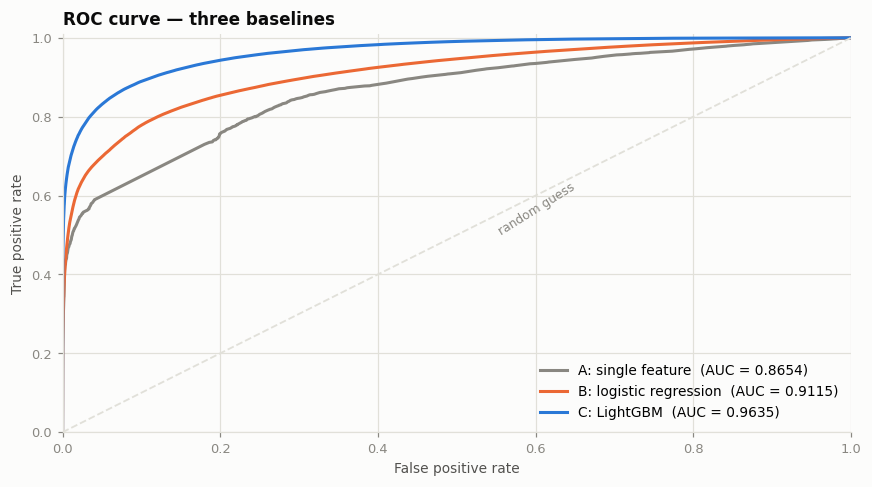

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for (name, oof), color in zip(oof_store.items(), [MUTED, ORANGE, BLUE]):
    fpr, tpr, _ = roc_curve(y_true, oof)
    step = max(1, len(fpr) // 3000)  # 描画点を間引いて軽量化
    ax.plot(fpr[::step], tpr[::step], color=color, label=f"{name}  (AUC = {results[name]:.4f})")
ax.plot([0, 1], [0, 1], color=GRID, ls="--", lw=1.2)
ax.text(0.55, 0.5, "random guess", color=MUTED, fontsize=8, rotation=32)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC curve — three baselines")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**ROC曲線の読み方。** 「このスコア以上を依存とみなす」という閾値を1から0へ動かしながら、
2つの割合を打った軌跡です。

- 横軸 FPR = 実際は依存でない人のうち、誤って依存側に置いてしまった割合
- 縦軸 TPR = 実際に依存の人のうち、正しく拾えた割合

閾値を緩めると拾える人が増える(縦軸↑)代わりに誤りも増える(横軸→)ので、右上に進みます。
**左上に近いほど良く、対角線がランダム**です。そして AUC はこの曲線の下の面積で、
「依存の人と非依存の人を1人ずつ選んだとき、依存の人の方が高いスコアになる確率」に等しくなります。

AUC は曲線を1つの数字に潰したものなので、曲線そのものを見ると
**どの領域で差がついているか**が分かります。同じAUCでも形が違うことがあり、
「誤検知を絶対に避けたい」なら左端だけを見る、といった読み方ができます。

LightGBM の曲線が一番左上に張り付いています。

### なぜ差がついたのか

第5章の「線形モデルはS字を表現できないのでは」という予想を確かめます。
`daily_screen_time_hours` に対する各モデルの予測値の平均を、実際の陽性率と重ねてみます。

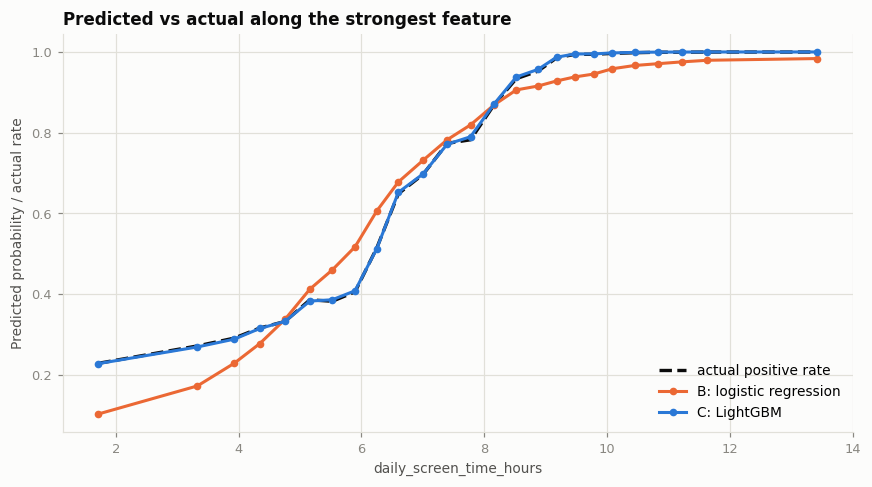

In [27]:
plot_df = pd.DataFrame({
    "x": X["daily_screen_time_hours"],
    "actual": y_true,
    "B: logistic regression": oof_lr,
    "C: LightGBM": oof_lgb,
}).dropna(subset=["x"])
bins = pd.qcut(plot_df["x"], 25, duplicates="drop")
g = plot_df.groupby(bins, observed=True).mean()
centers = [iv.mid for iv in g.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(centers, g["actual"], color=INK, ls="--", lw=2.2, label="actual positive rate")
ax.plot(centers, g["B: logistic regression"], color=ORANGE, marker="o", ms=4,
        label="B: logistic regression")
ax.plot(centers, g["C: LightGBM"], color=BLUE, marker="o", ms=4, label="C: LightGBM")
ax.set_xlabel("daily_screen_time_hours")
ax.set_ylabel("Predicted probability / actual rate")
ax.set_title("Predicted vs actual along the strongest feature")
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

予想どおりでした。LightGBM(青)は実際の陽性率(黒破線)にぴったり重なっています。

念のため補足すると、これは**学習データに当てはめた結果ではありません**。
プロットしているのは OOF(out-of-fold)予測で、各行の予測値は
**その行を学習に使っていないモデル**が出したものです(5-foldなので、fold0の行は
fold1〜4で学習したモデルが予測しています)。だから「未知の行に対する予測が実際の
陽性率と一致している」という意味になります。OOF予測を毎回保存しているのはこのためです。

一方ロジスティック回帰(オレンジ)はずれ方に癖があります。

- 低い域(2〜4時間)では実際より低く出る(実際0.23に対し0.10)
- 中間(5〜6時間)では逆に高く出る(実際0.39に対し0.46)
- 高い域(9時間以上)でまた低く出る(実際1.00に対し0.96〜0.98)

ロジスティック回帰の出力もシグモイドなのでS字にはなります。ただしそれは特徴量の線形和を
1本の滑らかな曲線に通しただけで、実データのような急な立ち上がりと両端の飽和は作れません。
決定木なら閾値で区切って階段状に近似できるので、この形をそのまま学習できます。

これが AUC で +0.05 の差になりました。EDAで形を見ておくとモデル選択の根拠になる、
という分かりやすい例だと思います。

### 特徴量重要度(ただし読み方に注意)

LightGBM の gain 重要度を見ます。その列での分岐が損失をどれだけ減らしたかの合計です。

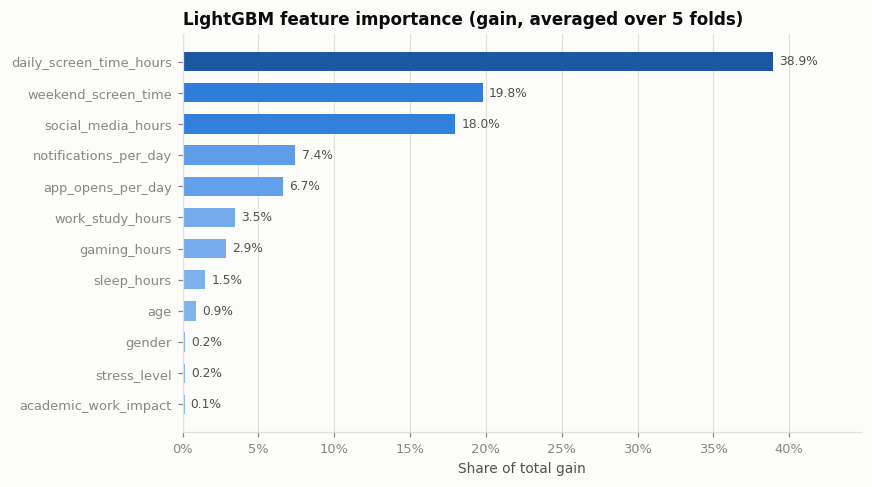

In [28]:
imp = pd.Series(np.mean(importances, axis=0), index=FEATURES).sort_values()
imp_norm = imp / imp.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = SEQ_CMAP(0.25 + 0.7 * (imp_norm / imp_norm.max()))
ax.barh(imp.index, imp_norm.values, color=colors, height=0.62)
for i, v in enumerate(imp_norm.values):
    ax.text(v + 0.004, i, f"{v:.1%}", va="center", fontsize=8, color=INK2)
ax.set_xlabel("Share of total gain")
ax.set_xlim(0, imp_norm.max() * 1.15)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("LightGBM feature importance (gain, averaged over 5 folds)")
ax.grid(axis="x")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

上位3つは EDA の相関分析どおり。カテゴリ3列が最下位というのも予想どおりでした。

引っかかるのは4〜5位です。`notifications_per_day` と `app_opens_per_day` が
合わせて14%を占めています。第6章では「相関がゼロだからノイズ」と読んだ列です。

相関と重要度が正面から食い違いました。よくある説明は
「69万行もあればノイズ列でもたまたま損失を下げる分岐が見つかり、それが積み上がる」
というものです。もっともらしいのですが、確かめずに採用すると危ないので測ります。

### 抜いて測る(ablation)

**ablation** は「切除」という意味で、完成したものから部品を1つ外して測り直し、
落ちた分をその部品の貢献とみなす手法です。重要度がモデル内部の集計にすぎないのに対して、
こちらは**評価指標そのものでの実測**になります。

似た手法に permutation importance(学習済みモデルでその列だけシャッフルして測る)が
ありますが、あれは「学習済みモデルがその列にどれだけ依存しているか」を測るもので、
「その列なしで学習し直したらどうなるか」とは別の問いです。今回は後者を知りたいので
抜いて学習し直します。

ついでに第4章で予想だけして放置していた**欠損フラグ**も、ここで測ります。

In [29]:
def cv_auc(cols, X=None):
    """指定した列だけで LightGBM を回して OOF AUC を返す(条件は上と同じ)。"""
    cats = [c for c in CAT_COLS if c in cols]
    Xa = (X_lgb if X is None else X)[cols]
    oof = np.zeros(len(Xa))
    for tr_idx, va_idx in folds:
        dtrain = lgb.Dataset(Xa.iloc[tr_idx], label=y_true.iloc[tr_idx],
                             categorical_feature=cats)
        dvalid = lgb.Dataset(Xa.iloc[va_idx], label=y_true.iloc[va_idx],
                             categorical_feature=cats, reference=dtrain)
        m = lgb.train(params, dtrain, num_boost_round=2000, valid_sets=[dvalid],
                      callbacks=[lgb.early_stopping(100, verbose=False),
                                 lgb.log_evaluation(0)])
        oof[va_idx] = m.predict(Xa.iloc[va_idx], num_iteration=m.best_iteration)
    return roc_auc_score(y_true, oof)


NOISE2 = ["notifications_per_day", "app_opens_per_day"]

drops = {
    "− notifications_per_day": ["notifications_per_day"],
    "− app_opens_per_day": ["app_opens_per_day"],
    "− この2列とも": NOISE2,
    "− sleep_hours": ["sleep_hours"],
    "− age": ["age"],
    "− カテゴリ3列": CAT_COLS,
    "(対照) − daily_screen_time_hours": ["daily_screen_time_hours"],
}

abl = {"全12列": auc_lgb}
for name, drop in drops.items():
    abl[name] = cv_auc([c for c in FEATURES if c not in drop])
    print(f"  {name} 済み", flush=True)

# 第4章の予想の検証: 欠損フラグ12列を「足す」ので、抜く側とは別に用意する
X_flag = X_lgb.copy()
flag_cols = []
for c in FEATURES:
    X_flag[f"{c}_isna"] = train[c].isna().astype("int8")
    flag_cols.append(f"{c}_isna")
abl["+ 欠損フラグ12列"] = cv_auc(FEATURES + flag_cols, X=X_flag)
print("  + 欠損フラグ12列 済み", flush=True)

abl["この2列だけで学習"] = cv_auc(NOISE2)

abl_df = pd.DataFrame({"OOF AUC": pd.Series(abl)})
abl_df["全12列との差"] = (abl_df["OOF AUC"] - auc_lgb).round(5)
abl_df.loc["この2列だけで学習", "全12列との差"] = np.nan  # 引き算に意味がないので空欄
abl_df.round(5)

  − notifications_per_day 済み
  − app_opens_per_day 済み
  − この2列とも 済み
  − sleep_hours 済み
  − age 済み
  − カテゴリ3列 済み
  (対照) − daily_screen_time_hours 済み
  + 欠損フラグ12列 済み


,OOF AUC,全12列との差
全12列,0.96349,0.00000
− notifications_per_day,0.95461,-0.00888
− app_opens_per_day,0.95614,-0.00735
− この2列とも,0.94451,-0.01898
− sleep_hours,0.96316,-0.00033
− age,0.96322,-0.00027
− カテゴリ3列,0.96353,0.00004
(対照) − daily_screen_time_hours,0.95342,-0.01007
+ 欠損フラグ12列,0.96349,-0.00000
この2列だけで学習,0.82087,NaN


2列を抜くと 0.019 落ちます。相関0.61 の `daily_screen_time_hours` を抜いた場合(0.010)の
倍近い。しかもこの2列だけで学習しても AUC 0.82 出ます。

**第6章の「ノイズ」は間違いでした。** 正しかったのは重要度のほうです。

第5章で「効かなそう」とまとめた4つのうち、`sleep_hours` と `age` は実際に小さい影響でした。
同じ棚に入れた2列だけが主力だったわけで、あの分類はほぼ当てずっぽうだったことになります。
一方カテゴリ3列は抜いても +0.00004 で、こちらは本当に無情報でした。

**第4章の予想は当たっていました。** 欠損フラグ12列を足しても −0.000003 で、動きません。
MCAR という読みは正しかったことになります。
予想が当たった例と外れた例が同じ表に並んだので、差がどこから来たのかを考える価値があります。
欠損フラグのほうは**検定で「差があるとは言えない」ところまで確認**してから予想しました。
一方この2列は**相関係数を見ただけ**で切り捨てていました。確認の深さが違いました。

### なぜ相関がゼロに見えたのか

値ごとに陽性率を出してみると分かります。

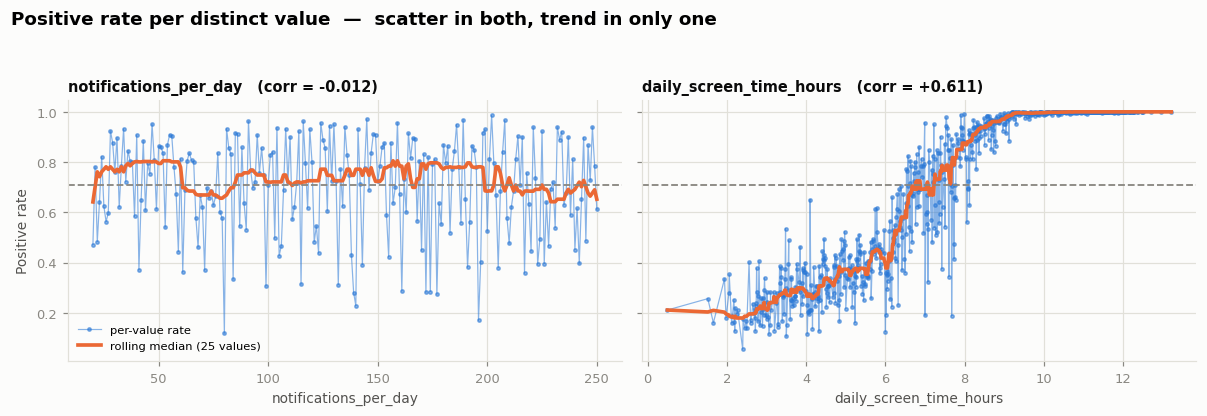

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, c in zip(axes, ["notifications_per_day", "daily_screen_time_hours"]):
    g = train.groupby(c, observed=True)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 200]
    ax.plot(g.index, g["mean"], color=BLUE, lw=0.8, marker="o", ms=2.2, alpha=0.55,
            label="per-value rate")
    # 25値の移動中央値。点のばらつきを均して「トレンドがあるか」だけを見る
    ax.plot(g.index, g["mean"].rolling(25, center=True, min_periods=5).median(),
            color=ORANGE, lw=2.4, label="rolling median (25 values)")
    ax.axhline(overall, color=MUTED, ls="--", lw=1.2)
    ax.set_xlabel(c)
    ax.set_title(f"{c}   (corr = {train[c].corr(train[TARGET]):+.3f})", fontsize=9.5)
    ax.grid(True)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Positive rate")
axes[0].legend(loc="lower left", fontsize=7.5)
fig.suptitle("Positive rate per distinct value  —  scatter in both, trend in only one",
             x=0.008, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

点のばらつきは左右どちらも大きいので、オレンジの移動中央値で均して比べます。

右の `daily_screen_time_hours` はトレンドがはっきり立ち上がります。相関係数が拾えるのはこの形。
左の `notifications_per_day` はトレンドが全体平均のまわりで平坦なままです。

一方で左の青い点は**隣の値でジグザグに飛んでいます**。
20→0.472、21→0.781、22→0.484、23→0.642、24→0.822 … 40→0.908、41→0.372。
上がっては下がるので、直線を当てると傾きがゼロになります。これが相関 −0.012 の正体でした。

情報は消えていません。**単調な成分がないだけ**で、値ごとの陽性率としては 0.12〜0.99 まで振れています。
木は値で分岐できるので、この振れをそのまま使えます。相関係数には使えません。

数字にすると形の違いがはっきりします。

In [31]:
rows = []
for c in ["notifications_per_day", "app_opens_per_day",
          "daily_screen_time_hours", "sleep_hours"]:
    g = train.groupby(c, observed=True)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 200]["mean"]
    rows.append({"列": c, "値の数": len(g), "陽性率のstd": g.std(),
                 "隣接値の平均差": np.abs(np.diff(g.values)).mean(),
                 "target との相関": train[c].corr(train[TARGET])})
pd.DataFrame(rows).set_index("列").round(3)

,値の数,陽性率のstd,隣接値の平均差,target との相関
列,,,,
notifications_per_day,231,0.192,0.225,-0.012
app_opens_per_day,166,0.195,0.217,0.063
daily_screen_time_hours,743,0.314,0.069,0.611
sleep_hours,436,0.080,0.068,0.043


`notifications_per_day` と `app_opens_per_day` は**隣接値の平均差が全体のstdより大きい**。
単調な成分がまったくなく、値そのものが陽性率を引き当てるテーブルになっています。
一方 `daily_screen_time_hours` は std 0.314 に対して隣接差 0.069 で、なめらかに見えます。

`sleep_hours` も隣接差(0.068)が std(0.080)に近く、性質としては同じギザギザ型です。
ただし振れ幅が 0.08 と小さいぶん、上の ablation どおり影響も小さくとどまります。
つまり効くかどうかを決めているのは「形」ではなく「振れ幅」でした。

### 補足: この指標は「なめらか」を過剰に出します

後になって分かったことを足しておきます。**隣接差と std の比は、
単調な成分が強い列ではジグザグを検出できません。** 分母のstdがS字で膨らむからです。

滑らかな成分(値の順に並べた移動中央値)を引いてから測り直すと、こうなります。

In [32]:
rows = []
rng_j = np.random.default_rng(0)
half_j = rng_j.integers(0, 2, size=len(train))
for c in ["notifications_per_day", "app_opens_per_day",
          "daily_screen_time_hours", "sleep_hours"]:
    g = train.groupby(c, observed=True)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 200]
    rate = g["mean"]
    jump = (rate - rate.rolling(15, center=True, min_periods=3).median()).dropna()
    parts = []
    for h in (0, 1):
        rh = train[half_j == h].groupby(c, observed=True)[TARGET].mean().reindex(g.index)
        parts.append(rh - rh.rolling(15, center=True, min_periods=3).median())
    both = pd.concat(parts, axis=1, keys=["a", "b"]).dropna()
    rows.append({"列": c, "陽性率のstd": rate.std(), "ジグザグのstd": jump.std(),
                 "ジグザグの半分割り相関": both["a"].corr(both["b"])})
pd.DataFrame(rows).set_index("列").round(3)

,陽性率のstd,ジグザグのstd,ジグザグの半分割り相関
列,,,
notifications_per_day,0.192,0.192,0.993
app_opens_per_day,0.195,0.194,0.994
daily_screen_time_hours,0.314,0.082,0.931
sleep_hours,0.080,0.064,0.890


**`daily_screen_time_hours` にもジグザグがあります。** 振れ幅 0.082、
独立した半分どうしの相関 0.931。標本のブレではありません。
S字が強いので、隣接差と std の比では見えなかっただけでした。

なので「ジグザグの列 / なめらかな列」という**種類の違いではなく、程度の差**です。
`notifications_per_day` が目立つのは、ジグザグのstd(0.192)が陽性率のstd(0.192)と
一致する、つまり**滑らかな成分をまったく持たない**からです。だから相関がゼロになります。

全12列で同じ測定をした表と、この性質が `max_bin` の設定にどう効くかは
別ノートブック([`max_bin` はどこまで上げるべきか](https://www.kaggle.com/code/kitopl/max-bin))
にまとめました。結論だけ書くと、**ジグザグを潰さないために必要なビン数は
「その列がもつ値の種類の数」で決まります**。

ここでの教訓は、指標の側にあります。
**「Xがない」と結論する前に、Xを隠しうるものが同じ系列に乗っていないか**を確かめること。
相関がゼロの列を切り捨てたのと、まったく同じ形の失敗でした。

最後に、このギザギザが偶然でないことを確かめます。
train をランダムに半分に割って、値ごとの陽性率が両側で一致するかを見ます。

In [33]:
rng = np.random.default_rng(0)
half = rng.random(len(train)) < 0.5
for c in ["notifications_per_day", "app_opens_per_day", "daily_screen_time_hours"]:
    a = train[half].groupby(c, observed=True)[TARGET].agg(["mean", "size"])
    b = train[~half].groupby(c, observed=True)[TARGET].agg(["mean", "size"])
    j = a.join(b, lsuffix="_a", rsuffix="_b", how="inner")
    j = j[(j["size_a"] >= 100) & (j["size_b"] >= 100)]
    print(f"{c:26s} 値数={len(j):>4}  半分どうしの陽性率の相関 r = "
          f"{j['mean_a'].corr(j['mean_b']):+.3f}")

notifications_per_day      値数= 231  半分どうしの陽性率の相関 r = +0.995
app_opens_per_day          値数= 166  半分どうしの陽性率の相関 r = +0.998
daily_screen_time_hours    値数= 726  半分どうしの陽性率の相関 r = +0.995


r = 0.99 以上。ギザギザは標本のブレではなく、データが持っている構造です。
だから木がそれを覚えれば、未知データでもそのまま効きます。

ただしこの検証には穴があります。値ごとの陽性率をそのまま比べているので、
**他の列の構成の違いが混ざったまま**です。ある値の行にたまたま長時間利用者が多ければ、
それも両半分に同じように現れるので相関は高く出ます。

この点は [Lookup-Transformer](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
の Finding 1 が正しく処理していて、**モデルを当てた後の残差**を独立した1/4どうしで
相関させています。構成効果がモデルに吸収されるので、帰無仮説のもとで0になる設計です。
その厳しい条件でも r = 0.72。同ノートブックは「合成データの生成器が元データの
値→ラベル対応を記憶した」と解釈し、値ごとの埋め込みテーブルを持つネットワークを組んでいます。

つまりここで見た構造自体は既知で、上の r = 0.995 は統制していないぶん大きく出た数字です。
それでも道筋は残しておきます。相関がゼロの列を ablation で疑ったら同じ場所に着いた、
という経路は再現しやすいはずです。

### このジグザグは何なのか — 使ってよいのか

「通知が40件だと陽性率0.908、41件だと0.372」に現実の意味はありません。因果としてナンセンスです。
これは第2章で触れた **artifact**、つまり生成器が残した痕跡です。
小さな元データで学習した生成モデルが具体的な値を部分的に暗記してしまい、
サンプリングするとその値が元のラベルごと再現される。生成器の過学習が出力に漏れた状態です。

使ってよいかは、**testでも同じ癖が出るか**で決まります。値の集合を確認します。

In [34]:
rows = []
for c in ["notifications_per_day", "app_opens_per_day", "daily_screen_time_hours"]:
    a, b = set(train[c].dropna().unique()), set(test[c].dropna().unique())
    rows.append({"列": c, "trainの値数": len(a), "testの値数": len(b), "共通": len(a & b),
                 "trainに無い値をもつtestの行数": int(test[c].isin(list(b - a)).sum())})
pd.DataFrame(rows).set_index("列")

,trainの値数,testの値数,共通,trainに無い値をもつtestの行数
列,,,,
notifications_per_day,231,231,231,0
app_opens_per_day,166,166,166,0
daily_screen_time_hours,1389,1349,1341,9


主要2列は **test の全行が train に存在する値**でした(231/231、166/166、未知の値は0行)。
lookup テーブルはそのまま転用できます。private LB も同じ `test.csv` の行の一部なので、
public だけ通用して private で崩れる、という心配もありません。

ただし範囲はそこまでです。**これは Playground 限定の技術**です。
実データを相手にするなら、この癖に依存したモデルは崩れます。
「相関がゼロでも列を捨てるな」は持ち帰れる教訓ですが、
「値ごとの対応を覚えさせろ」は持ち帰れません。データの性質を3つに分けると:

| 種類 | 例 | 現実的な意味 |
|---|---|---|
| 主催者が意図した設計 | 目的変数の定義、評価指標 | — |
| **生成の副産物(artifact)** | **値ごとの陽性率のジグザグ**、予算制約が100%成立 | **なし** |
| 元データ由来の本物の関係 | スクリーンタイムのS字 | ある |

2段目を突くとスコアは上がりますが、そこで学べるのはこのデータセットの作り方だけです。

### 学んだこと

相関係数は直線的な関係しか測れません。第5章でその話をして、S字のような
「相関では過小評価される形」に気をつけたつもりでした。
それでも同じ罠の別バージョンで足をすくわれています。

- **相関がゼロでも「効かない」とは言えない**。単調でない関係には最初から盲目
- 分位でならしたグラフも同じ理由で騙される。この2列は20等分で見ると平坦だった
- EDAで列を捨てる前に、**値ごとの目的変数の平均**を一度プロットするとよさそう
- プロットするときは**滑らかな成分を引いてから**見る。補足のとおり、S字が強い列では
  ジグザグが埋もれます。指標を1つ通しただけで「ない」と結論しない
- そして重要度と相関が食い違ったら、ablation で決着をつける。今回は重要度が正しかった

### 提出ファイルの作成

In [35]:
submission = pd.DataFrame({ID: test[ID], TARGET: test_pred})
submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(296302, 2)


,id,addicted_label
0,691369,0.999583
1,691370,0.962871
2,691371,0.934654
3,691372,0.989485
4,691373,0.998055


この構成で提出したところ Public LB は 0.96511 でした(CV 0.96349)。

差が0.0016しかないので、手元のCVは信用してよさそうです。
つまり今後は提出回数を使わずに、CVだけ見て改善を判断できます。
ここが大きく乖離するようならCVの切り方から見直すことになるので、最初に確認しておくと安心です。

<a id="11"></a>
## 11. まとめと次にやること

分かったことを整理すると、

- 欠損は全列に4〜20%あるが MCAR。欠損フラグを足しても動かないことを実測で確認した
- 主要3列が急なS字。この形のせいで線形モデルとGBDTでAUCが0.05違った
- `notifications_per_day` / `app_opens_per_day` は相関ゼロだが、抜くとAUCが0.019落ちる主力だった
- 総量 = 内訳合計 + 残差 という構造があり、派生特徴量のネタになる
- CV 0.9635 と LB 0.96511 がほぼ一致。以降はCVを信じて回せる

役に立ったのは、EDAで関係の「形」まで見てからモデルを選んだことです。
相関係数だけ眺めていたら、S字にも気づかずいきなりLightGBMを回していたと思います。
簡単なモデルから順に作るとスコアの内訳が分解できるのもおすすめです。

一方でいちばんの収穫は、**その形の見方が足りずに列を捨てかけた**ことでした。
20等分して平坦だから無情報、というのは第5章の「形を見る」の当て方として粗すぎました。
相関でも分位別のグラフでも見えない関係があるので、疑わしい列は抜いて測るのが確実です。

次にやること:

- 派生特徴量(`daily - 内訳合計`、`weekend / daily`、`social / daily`)を足す
- 値ごとの陽性率が飛ぶ構造を、木の解像度(`max_bin`)や target encoding でどう活かすか
- ハイパーパラメータのチューニング
- XGBoost / CatBoost と比べてアンサンブル

## 参考にしたノートブック

第6章と第10章で触れた内容は、以下で先に、より厳密に扱われています。

- [**S6E8 — Lookup-Transformer**](https://www.kaggle.com/code/tamerlanomralinov/s6e8-lookup-transformer-insights-lb-0-97041)
  (tamerlanomralinov)— 値が magnitude ではなく lookup キーであること(Finding 1)と、
  時間の予算制約(Finding 2)。第10章の残差による検証方法はここから学びました
- [**S6E8: why gaming_hours helps but adds nothing new**](https://www.kaggle.com/code/georgymamarin/s6e8-why-gaming-hours-helps-but-adds-nothing-new)
  (Georgy Mamarin)— 単変量AUCと条件付きAUCと ablation が食い違う話。
  「条件付けで消える列が、モデルに足すと効く」という本ノートブックと逆向きの例
- [**S6E8: What Moved the Score, and What Didn't**](https://www.kaggle.com/code/tomasa2/s6e8-what-moved-the-score-and-what-didn-t)
  (tomasa2)— 試した施策と効果の一覧

気づいた点や改善案があればコメントで教えてください。